# EEG validation figures

Validation-only comparisons of the fixed baselines and NAS-selected architectures. Locked test results are not used.

In [42]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

## Fixed baselines vs. NAS-selected architectures

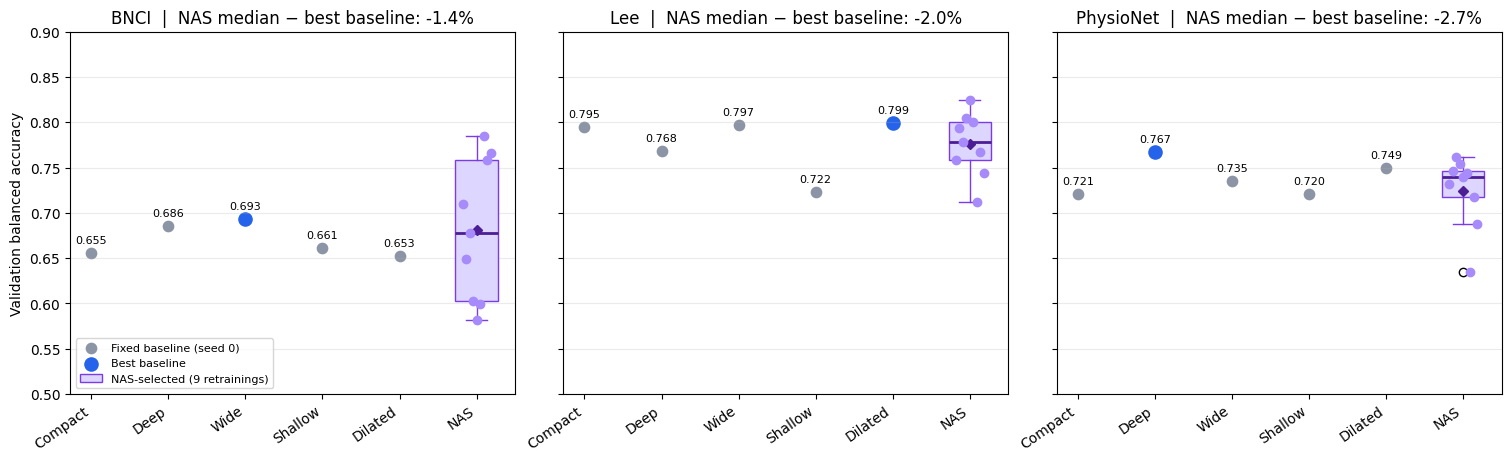

In [43]:
DATA_ROOT = Path('../data') if Path('../data').exists() else Path('data')
baseline_calibration_files = sorted(DATA_ROOT.glob('seed-*/benchmarking/calibration/*/calibration_results.jsonl'))
baseline_files = baseline_calibration_files or sorted(DATA_ROOT.glob('seed-0/benchmarking/*/*/baseline_results.jsonl'))
calibration_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/calibration/*/calibration_results.jsonl'))
baseline_rows = [
    {
        'seed': entry['seed'], 'dataset': entry['dataset'], 'model': entry['baseline'],
        'validation': entry['validation']['balanced_accuracy'],
    }
    for path in baseline_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
    if not baseline_calibration_files or entry['epoch'] == 40
]
nas_rows = [
    {
        'seed': entry['seed'], 'source': entry['source_dataset'],
        'dataset': entry['target_dataset'], 'validation': entry['validation']['balanced_accuracy'],
    }
    for path in calibration_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
    if entry['epoch'] == 40
]
baselines = pd.DataFrame(baseline_rows)
nas_results = pd.DataFrame(nas_rows)
dataset_labels = {'bnci2014_001': 'BNCI', 'lee2019_mi': 'Lee', 'physionet_mi': 'PhysioNet'}
model_labels = {
    'compact_eegnet': 'Compact', 'deep_separable': 'Deep', 'wide_eegnet': 'Wide',
    'shallow_temporal': 'Shallow', 'dilated_temporal': 'Dilated',
}
model_order = list(model_labels)
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True, constrained_layout=True)
for axis, dataset in zip(axes, dataset_labels, strict=True):
    baseline = baselines[baselines['dataset'] == dataset]
    nas = nas_results[nas_results['dataset'] == dataset].sort_values(['seed', 'source'])
    x = list(range(len(model_order)))
    for position, name in enumerate(model_order):
        values = baseline.loc[baseline['model'] == name, 'validation']
        offsets = [(index - (len(values) - 1) / 2) * 0.08 for index in range(len(values))]
        axis.scatter(
            [position + offset for offset in offsets], values, s=45, color='#8b95a5', zorder=3,
            label='Fixed baselines' if position == 0 else None,
        )
        if len(values) > 1:
            axis.boxplot(
                values, positions=[position], widths=0.55, patch_artist=True,
                boxprops={'facecolor': '#e2e8f0', 'edgecolor': '#64748b'},
                medianprops={'color': '#1e3a8a', 'linewidth': 2},
                whiskerprops={'color': '#64748b'}, capprops={'color': '#64748b'},
            )
    nas_x = len(model_order)
    box = axis.boxplot(
        nas['validation'], positions=[nas_x], widths=0.55, patch_artist=True,
        showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': '#4c1d95', 'markeredgecolor': '#4c1d95', 'markersize': 5},
        boxprops={'facecolor': '#ddd6fe', 'edgecolor': '#7c3aed'},
        medianprops={'color': '#4c1d95', 'linewidth': 2},
        whiskerprops={'color': '#7c3aed'}, capprops={'color': '#7c3aed'},
    )
    box['boxes'][0].set_label('NAS-selected (9 retrainings)')
    offsets = [(index - (len(nas) - 1) / 2) * 0.045 for index in range(len(nas))]
    axis.scatter([nas_x + offset for offset in offsets], nas['validation'], color='#a78bfa', zorder=3)
    delta = nas['validation'].median() - baseline.groupby('model')['validation'].median().max()
    axis.set_title(f"{dataset_labels[dataset]}  |  NAS median − best baseline: {delta:+.1%}")
    axis.set_xticks([*x, nas_x], [*[model_labels[name] for name in model_order], 'NAS'], rotation=35, ha='right')
    axis.set_ylim(0.5, 0.9)
    axis.grid(axis='y', alpha=0.25)
axes[0].set_ylabel('Validation balanced accuracy')
axes[0].legend(loc='lower left', fontsize=8)
plt.show()

## NAS final-training calibration

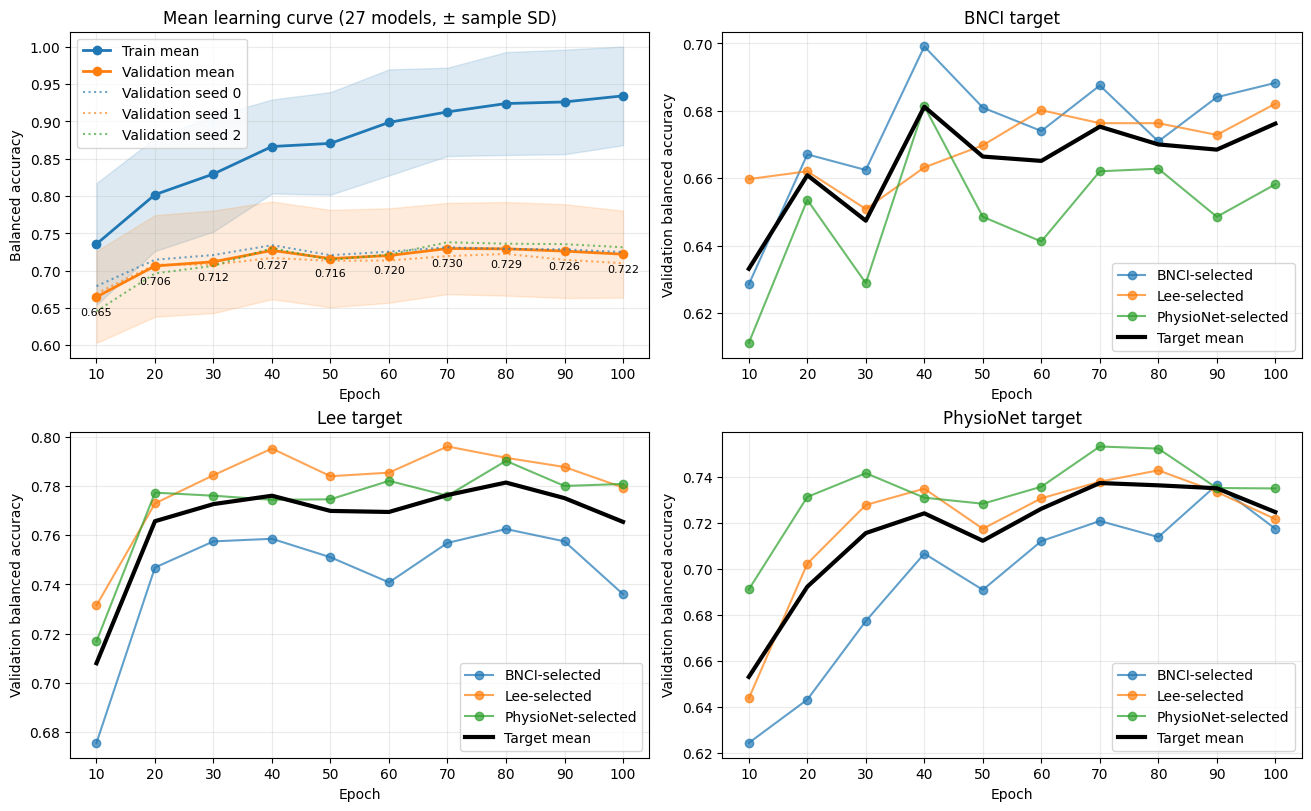

In [44]:
DATA_ROOT = Path('../data') if Path('../data').exists() else Path('data')
calibration_files = sorted(DATA_ROOT.glob('seed-*/eeg-parzen/calibration/*/calibration_results.jsonl'))
if len(calibration_files) != 3:
    raise RuntimeError(f'Expected three calibration files, found {len(calibration_files)}')
calibration = pd.DataFrame(
    {
        'seed': entry['seed'],
        'source': entry['source_dataset'],
        'target': entry['target_dataset'],
        'epoch': entry['epoch'],
        'train': entry['train']['balanced_accuracy'],
        'validation': entry['validation']['balanced_accuracy'],
    }
    for path in calibration_files
    for entry in (json.loads(line) for line in path.open() if line.strip())
)
calibration['group'] = calibration.apply(
    lambda row: 'Diagonal' if row['source'] == row['target'] else 'Transfer', axis=1
)
overall = calibration.groupby('epoch').agg(
    train_mean=('train', 'mean'), train_sd=('train', 'std'),
    validation_mean=('validation', 'mean'), validation_sd=('validation', 'std'),
)
overall['generalization_gap'] = overall['train_mean'] - overall['validation_mean']
target_summary = calibration.groupby(['target', 'epoch'])['validation'].mean().reset_index()
component_summary = calibration.groupby(['target', 'source', 'epoch'])['validation'].mean().reset_index()
fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
mean_axis = axes[0, 0]
for metric, label, color in [('train', 'Train', 'tab:blue'), ('validation', 'Validation', 'tab:orange')]:
    mean, sd = overall[f'{metric}_mean'], overall[f'{metric}_sd']
    mean_axis.plot(overall.index, mean, marker='o', linewidth=2, label=f'{label} mean', color=color)
    mean_axis.fill_between(overall.index, mean - sd, mean + sd, alpha=0.15, color=color)
for seed, group in calibration.groupby('seed'):
    curve = group.groupby('epoch')['validation'].mean()
    mean_axis.plot(curve.index, curve, linestyle=':', alpha=0.65, label=f'Validation seed {seed}')
for epoch, value in overall['validation_mean'].items():
    mean_axis.annotate(f'{value:.3f}', (epoch, value), xytext=(0, -13), textcoords='offset points', ha='center', fontsize=8)
dataset_labels = {'bnci2014_001': 'BNCI', 'lee2019_mi': 'Lee', 'physionet_mi': 'PhysioNet'}
target_axes = dict(zip(dataset_labels, [axes[0, 1], axes[1, 0], axes[1, 1]], strict=True))
for target, axis in target_axes.items():
    target_components = component_summary[component_summary['target'] == target]
    for source, group in target_components.groupby('source'):
        axis.plot(group['epoch'], group['validation'], marker='o', alpha=0.7, label=f'{dataset_labels[source]}-selected')
    target_mean = target_summary[target_summary['target'] == target]
    axis.plot(target_mean['epoch'], target_mean['validation'], color='black', linewidth=3, label='Target mean')
    axis.set_title(f'{dataset_labels[target]} target')
for axis in axes.flat:
    axis.set(xlabel='Epoch', xticks=range(10, 101, 10))
    axis.grid(alpha=0.25)
    axis.legend()
mean_axis.set(ylabel='Balanced accuracy', title='Mean learning curve (27 models, ± sample SD)')
for axis in target_axes.values():
    axis.set_ylabel('Validation balanced accuracy')
plt.show()
target_table = target_summary.pivot(index='epoch', columns='target', values='validation').rename(columns=dataset_labels)
component_table = component_summary.pivot(index='epoch', columns=['target', 'source'], values='validation').rename(columns=dataset_labels)
# display(overall.round(4), target_table.round(4), component_table.round(4))